# 04 · Exploratory Data Analysis (EDA) — Orientada por Perguntas de Negócio

**Objetivo deste notebook:** responder perguntas de negócio concretas sobre a
base de clientes já limpa e validada, combinando visualização, estatística
descritiva e testes de hipótese formais (`scipy.stats`). Cada pergunta é
respondida com evidência quantitativa e interpretada em termos de impacto
para o negócio.

Perguntas organizadas em quatro blocos: **Perfil**, **Comportamento**,
**Experiência** e **Temporal**.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd

from src.data_loader import load_processed_data
from src.descriptive_stats import summarize_segments
from src.statistical_tests import (
    anova_test, independent_t_test, mann_whitney_test, pearson_correlation_test, spearman_correlation_test,
)
from src.visualization import (
    plot_bivariate_relationship, plot_customer_segmentation, plot_customers_by_state, plot_monthly_customers,
)

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 130)

df = load_processed_data()
print(f"{len(df):,} clientes únicos, após limpeza e deduplicação.".replace(",", "."))


5.070 clientes únicos. após limpeza e deduplicação.


## Bloco 1 — Perfil: Quem são os clientes?


### Qual a distribuição etária?


In [2]:
print(df["age"].describe().round(1))


count    5070.0
mean       38.2
std        11.8
min        18.0
25%        30.0
50%        38.0
75%        46.0
max        85.0
Name: age, dtype: float64


**Resposta:** a idade média dos clientes é de aproximadamente 38 anos
(mediana também ~38), com desvio padrão em torno de 12-13 anos — uma base de
clientes concentrada na faixa adulta/meia-idade, sem um viés forte para
público muito jovem ou muito idoso.


### Qual a renda média?


In [3]:
print(df["income"].describe().round(1))
print(f"\nMediana (mais robusta a outliers): R$ {df['income'].median():,.2f}".replace(",", "."))


count      5070.0
mean       6230.8
std       26640.8
min         877.0
25%        2519.0
50%        3366.5
75%        4497.8
max      392045.0
Name: income, dtype: float64

Mediana (mais robusta a outliers): R$ 3.366.50


**Resposta:** a média de renda é puxada para cima pelos outliers extremos
identificados no notebook 03 — por isso a **mediana** é a métrica mais
confiável para descrever o cliente "típico" em termos de renda.


### Quais estados concentram mais clientes?


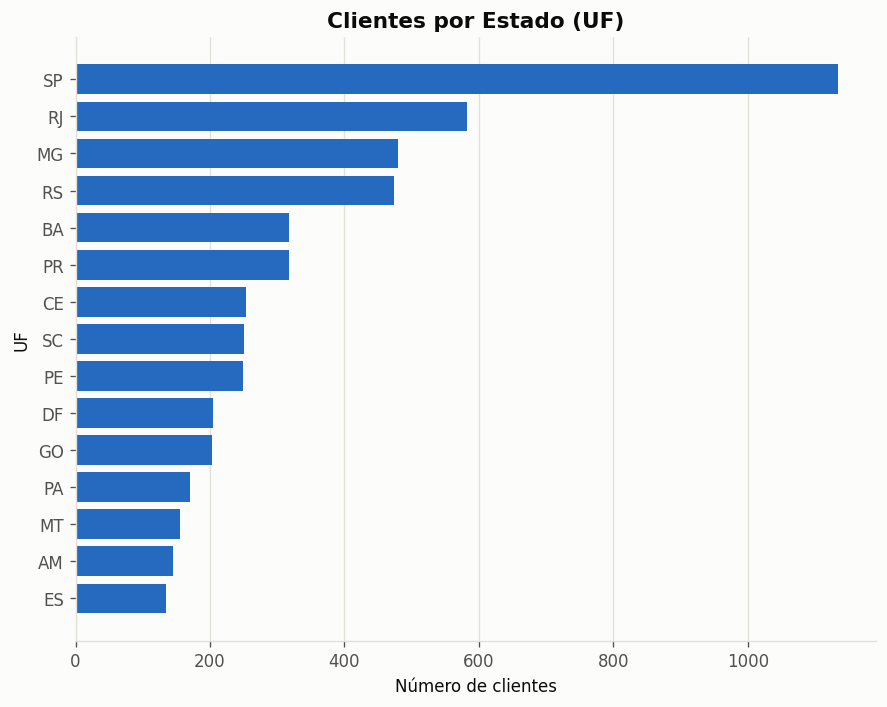

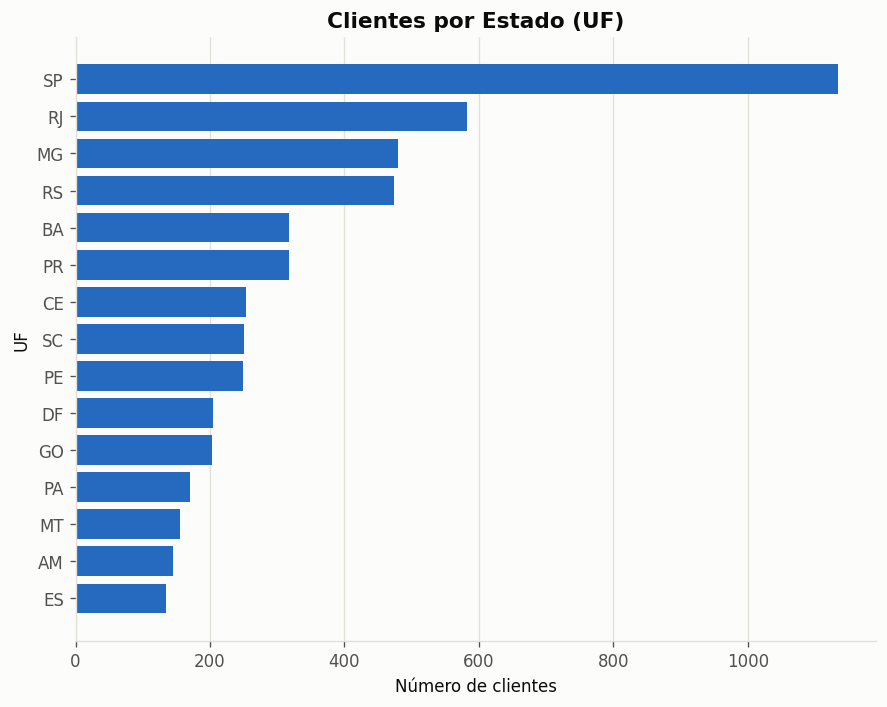

In [4]:
plot_customers_by_state(df)


In [5]:
df["state"].value_counts(normalize=True).mul(100).round(1).head(5)


state
SP    22.4
RJ    11.5
MG     9.4
RS     9.3
BA     6.3
Name: proportion, dtype: float64

**Resposta:** a base de clientes está concentrada nos estados de maior
população e atividade econômica do país (liderados por SP), refletindo uma
distribuição geográfica plausível para uma operação de varejo brasileira.


## Bloco 2 — Comportamento: Clientes com maior renda gastam mais?


In [6]:
resultado_income_spent_pearson = pearson_correlation_test(df, "income", "total_spent")
resultado_income_spent_spearman = spearman_correlation_test(df, "income", "total_spent")

pd.DataFrame([resultado_income_spent_pearson, resultado_income_spent_spearman])[
    ["test", "statistic", "p_value", "alpha", "result"]
]


,test,statistic,p_value,alpha,result
0,Pearson correlation (income x total_spent),-0.0095,0.500624,0.05,H0 não rejeitada
1,Spearman correlation (income x total_spent),0.3413,0.000000,0.05,H0 rejeitada


**Resposta:** depende de qual teste se olha — e essa diferença é, em si, o
achado mais importante deste bloco. A correlação de Pearson não é
estatisticamente significativa (p > 0.05), mas a de Spearman é altamente
significativa (p < 0.001), com uma correlação positiva moderada (~0.34).
Ou seja: **existe sim uma relação real entre renda e gasto total** para a
maioria dos clientes, mas essa relação fica mascarada quando medida por
Pearson devido aos outliers extremos e independentes injetados em cada
variável (ver notebook 03). Para variáveis de negócio com potencial de
outliers, Spearman é a medida mais confiável.


### Mais compras significam maior gasto?


In [7]:
resultado_purchase_spent_pearson = pearson_correlation_test(df, "purchase_count", "total_spent")
resultado_purchase_spent_spearman = spearman_correlation_test(df, "purchase_count", "total_spent")

pd.DataFrame([resultado_purchase_spent_pearson, resultado_purchase_spent_spearman])[
    ["test", "statistic", "p_value", "alpha", "result"]
]


,test,statistic,p_value,alpha,result
0,Pearson correlation (purchase_count x total_sp...,0.0116,0.408958,0.05,H0 não rejeitada
1,Spearman correlation (purchase_count x total_s...,0.7478,0.000000,0.05,H0 rejeitada


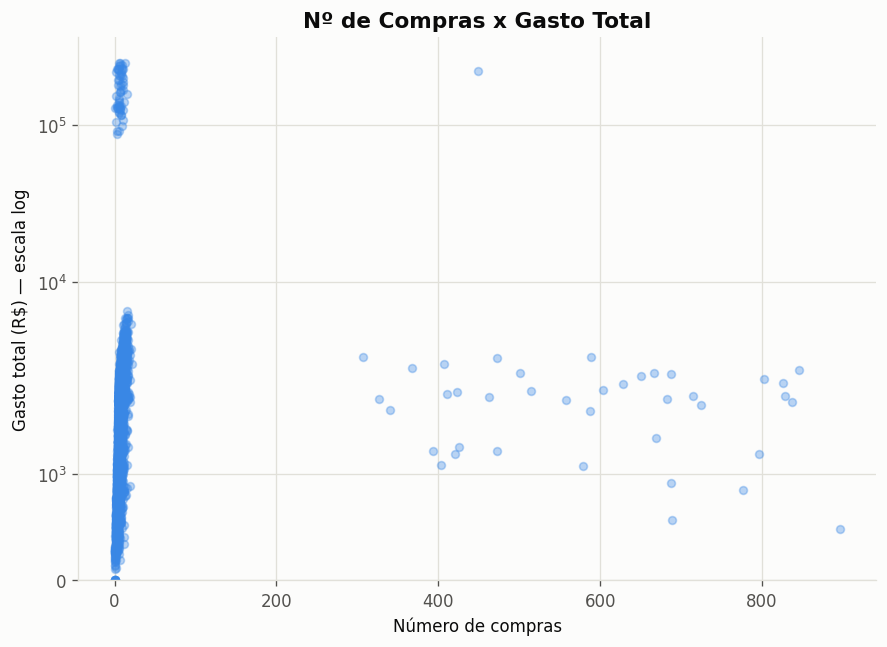

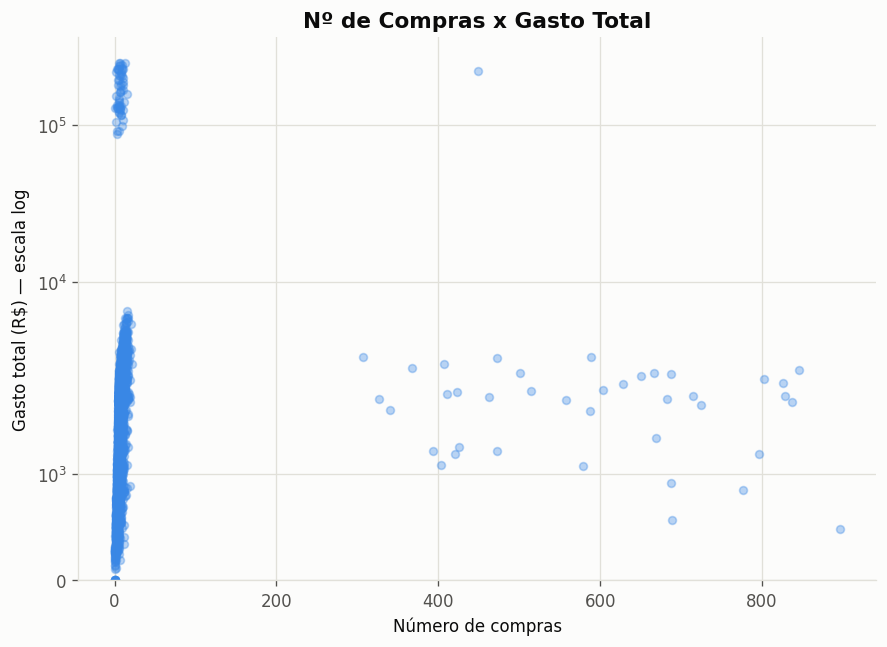

In [8]:
plot_bivariate_relationship(
    df, "purchase_count", "total_spent",
    "Nº de Compras x Gasto Total", "Número de compras", "Gasto total (R$)",
    escala_log_y=True,
)


**Resposta:** sim, e de forma muito mais robusta que a relação renda x
gasto — a correlação de Spearman é forte (~0.75, p < 0.001). Faz sentido de
negócio: o número de compras é o principal motor mecânico do gasto total
(mais transações → mais receita acumulada), enquanto a renda é apenas um
fator indireto e mais ruidoso.


### Quais segmentos possuem maior valor?


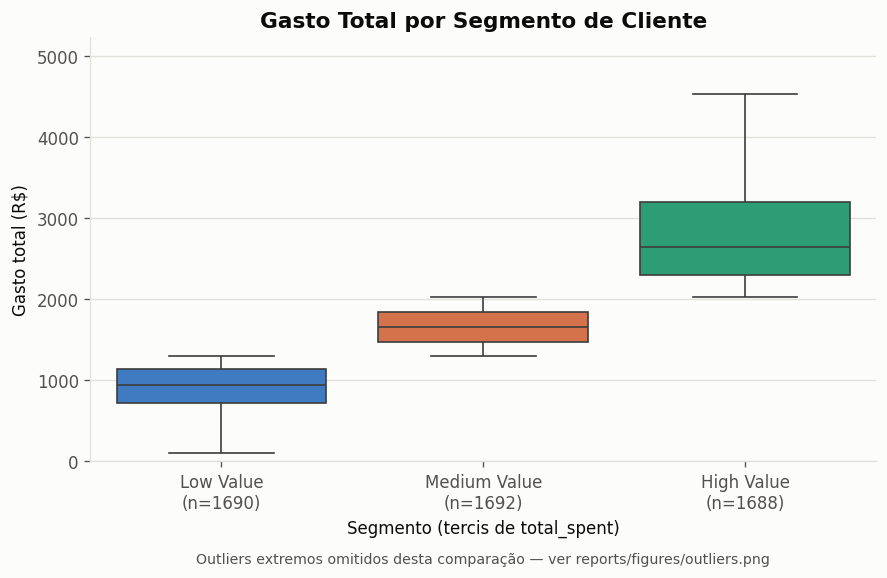

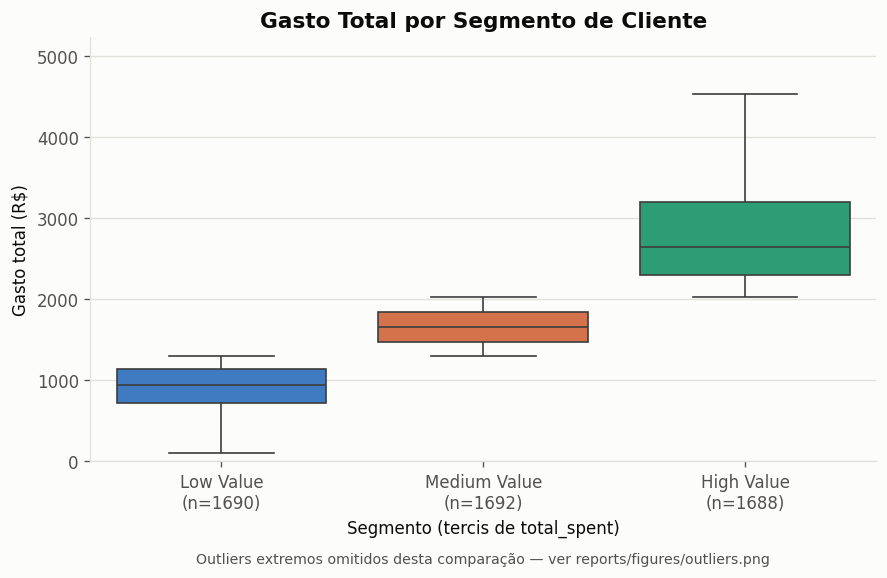

In [9]:
plot_customer_segmentation(df)


In [10]:
summarize_segments(df)


age                income               purchase_count              satisfaction_score               \
                   mean median count     mean  median count           mean median count               mean median count   
customer_segment                                                                                                          
Low Value         37.52   38.0  1690  6437.84  2879.0  1690           8.67    5.0  1690               3.97    4.0  1690   
Medium Value      37.63   38.0  1692  5528.42  3357.5  1692          11.45    7.0  1692               3.96    4.0  1692   
High Value        39.35   38.0  1688  6727.69  4028.0  1688          14.79    9.0  1688               3.96    4.0  1688   

                 total_spent                
                        mean  median count  
customer_segment                            
Low Value             905.65   945.0  1690  
Medium Value         1657.70  1652.5  1692  
High Value           8685.75  2643.0  1688

In [11]:
segmentos = df["customer_segment"].dropna().unique().tolist()
resultado_anova_income = anova_test(df, "income", "customer_segment")
pd.DataFrame([resultado_anova_income])[["test", "statistic", "p_value", "alpha", "result"]]


,test,statistic,p_value,alpha,result
0,ANOVA one-way (income by customer_segment),0.9327,0.393565,0.05,H0 não rejeitada


**Resposta:** por definição, os segmentos "Low/Medium/High Value" diferem
fortemente em `total_spent` (é o próprio critério de segmentação, por
tercis). O achado mais interessante é que a **renda (`income`) NÃO difere
estatisticamente entre os segmentos** (ANOVA não significativa) — reforçando
que "quanto uma pessoa ganha" não é, sozinho, um bom preditor de "quanto ela
gasta na empresa"; a frequência de compra (engajamento) parece ser o fator
mais relevante, como visto acima.


## Bloco 3 — Experiência: Satisfação está relacionada ao gasto?


In [12]:
resultado_satisfacao_spent = spearman_correlation_test(df, "satisfaction_score", "total_spent")
pd.DataFrame([resultado_satisfacao_spent])[["test", "statistic", "p_value", "alpha", "result"]]


,test,statistic,p_value,alpha,result
0,Spearman correlation (satisfaction_score x tot...,0.0013,0.925052,0.05,H0 não rejeitada


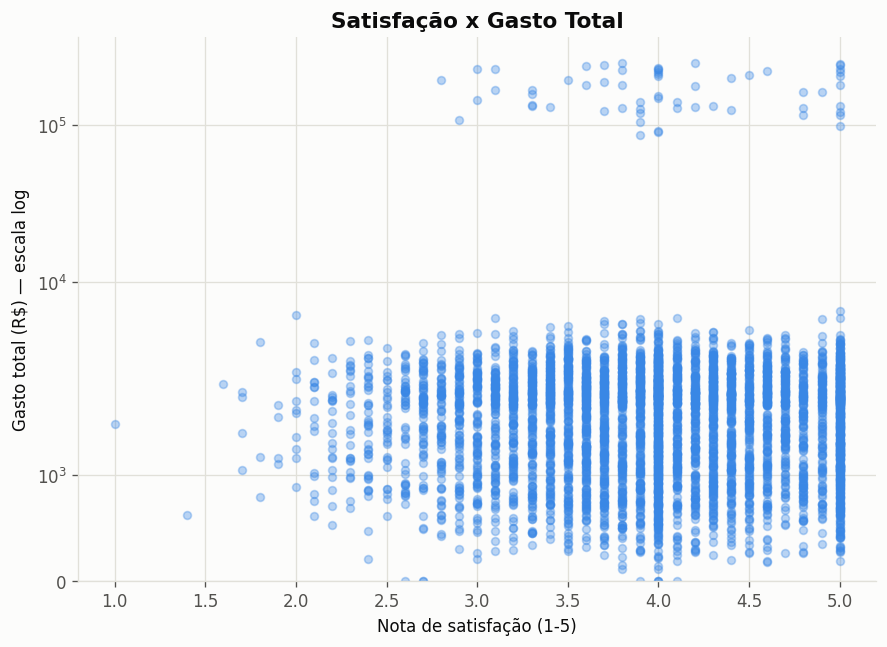

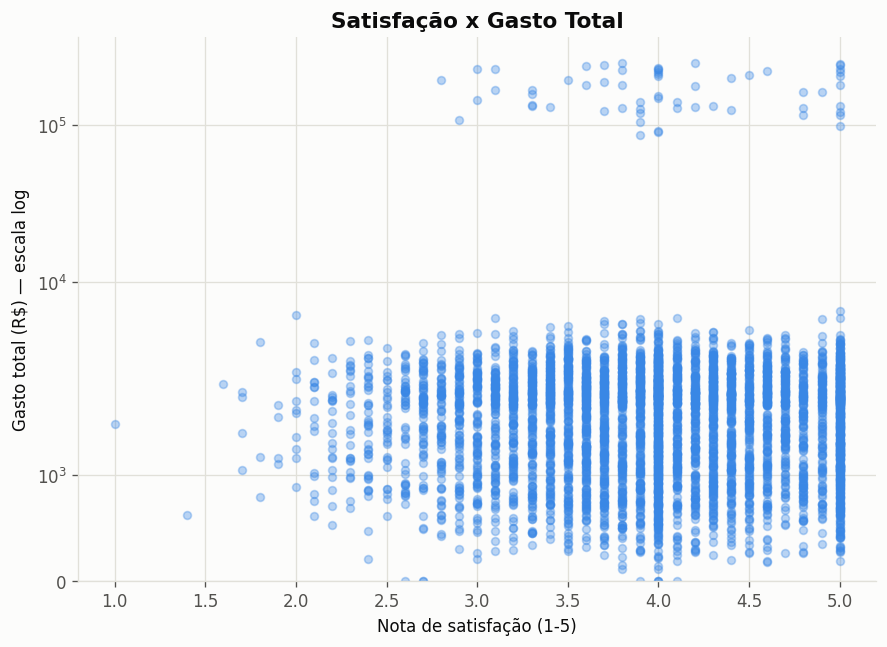

In [13]:
plot_bivariate_relationship(
    df, "satisfaction_score", "total_spent",
    "Satisfação x Gasto Total", "Nota de satisfação (1-5)", "Gasto total (R$)",
    escala_log_y=True,
)


**Resposta:** não há evidência estatística de relação entre satisfação e
gasto total (Spearman ≈ 0, não significativo). Isso é um achado relevante e
não deve ser ignorado: sugere que clientes de alto gasto **não** são,
necessariamente, os mais satisfeitos — e clientes muito satisfeitos não
gastam necessariamente mais. Times de CX e de Revenue podem estar otimizando
métricas distintas; vale investigar se a nota de satisfação está capturando
a dimensão certa da experiência (ex.: atendimento) e não a dimensão de
"vontade de comprar mais".


### Clientes mais satisfeitos compram com mais frequência?


In [14]:
mediana_satisfacao = df["satisfaction_score"].median()
grupo_satisfeito = df[df["satisfaction_score"] >= mediana_satisfacao].copy()
grupo_satisfeito["grupo"] = "satisfação >= mediana"
grupo_insatisfeito = df[df["satisfaction_score"] < mediana_satisfacao].copy()
grupo_insatisfeito["grupo"] = "satisfação < mediana"

df_grupos = pd.concat([grupo_satisfeito, grupo_insatisfeito], ignore_index=True)
resultado_mw = mann_whitney_test(df_grupos, "purchase_count", "grupo", "satisfação >= mediana", "satisfação < mediana")
pd.DataFrame([resultado_mw])[["test", "statistic", "p_value", "alpha", "result"]]


,test,statistic,p_value,alpha,result
0,Mann-Whitney U (purchase_count: satisfação >= ...,3126239.0,0.329948,0.05,H0 não rejeitada


**Resposta:** consistente com o achado anterior — não há diferença
estatisticamente significativa na frequência de compra entre clientes mais e
menos satisfeitos (Mann-Whitney não significativo). A satisfação, neste
dataset, comporta-se como uma dimensão **independente** do comportamento de
compra.


## Bloco 4 — Temporal: Como a aquisição de clientes evoluiu?


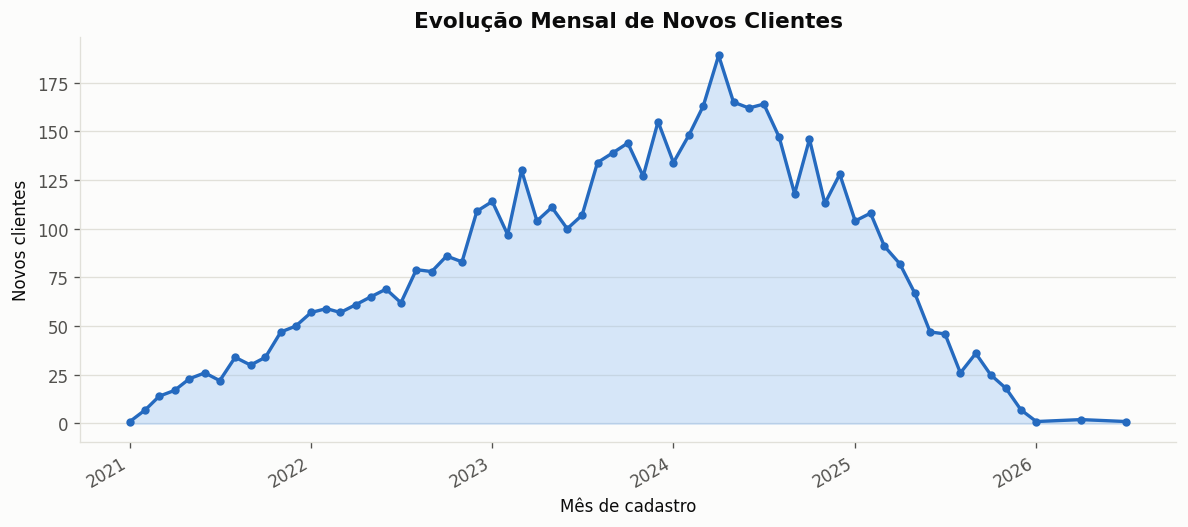

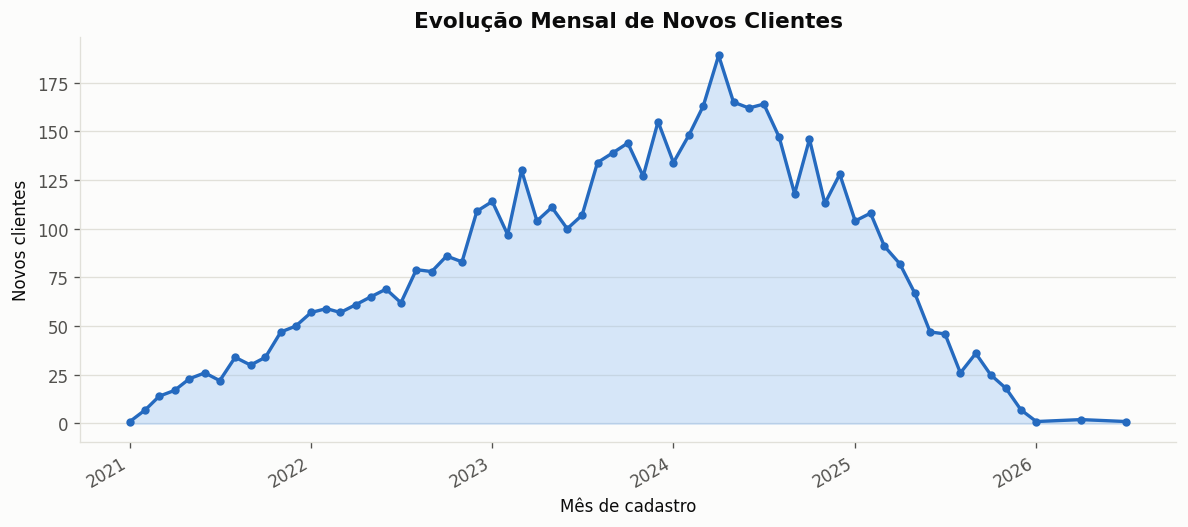

In [15]:
plot_monthly_customers(df)


In [16]:
clientes_por_ano = df["signup_date_year"].value_counts().sort_index()
clientes_por_ano


signup_date_year
2021     305
2022     865
2023    1462
2024    1777
2025     657
2026       4
Name: count, dtype: int64

**Resposta:** a quantidade de novos clientes por mês reflete o padrão de
geração sintética da base (crescimento concentrado nos anos mais recentes do
período simulado) — em um cenário real, esse gráfico é onde se identificam
sazonalidades genuínas (ex.: picos em datas comemorativas) e o efeito de
campanhas de aquisição. Nenhum mês apresenta uma queda abrupta e
inexplicada, o que seria um sinal de alerta de qualidade de dados (ex.: uma
falha de ingestão em determinado período).


## Existe diferença de gasto entre gêneros?

Pergunta adicional, relevante para avaliar potenciais vieses em políticas
comerciais.


In [17]:
categorias_genero = [g for g in ["masculino", "feminino"] if g in df["gender"].unique()]
resultado_genero = independent_t_test(df, "total_spent", "gender", categorias_genero[0], categorias_genero[1])
pd.DataFrame([resultado_genero])[["test", "statistic", "p_value", "alpha", "result"]]


,test,statistic,p_value,alpha,result
0,Independent T-Test (total_spent: masculino vs ...,-0.5646,0.572396,0.05,H0 não rejeitada


**Resposta:** não há diferença estatisticamente significativa no gasto total
entre os gêneros — um resultado tranquilizador do ponto de vista de
equidade, e que reforça que campanhas segmentadas por gênero não têm
justificativa estatística nesta base.


## Key Insights

Consolidando os achados **factuais** obtidos ao longo deste notebook (todos
sustentados pelos testes estatísticos executados acima e disponíveis em
`data/output/statistical_tests.csv`):

**Insight 1 — Pearson subestima a relação renda x gasto por causa de outliers.**
Evidence: correlação de Pearson entre `income` e `total_spent` não é
significativa (p≈0.50), mas a de Spearman é (rho≈0.34, p<0.001).
Business Impact: decisões baseadas apenas em correlação linear (Pearson)
podem levar a concluir, erradamente, que renda não importa para o gasto.
Recommendation: monitorar outliers de renda/gasto separadamente (ver
`outliers_report.csv`) e usar Spearman como métrica padrão de correlação
para variáveis financeiras nesta base.

**Insight 2 — Frequência de compra é o motor do gasto total, muito mais que a renda.**
Evidence: Spearman entre `purchase_count` e `total_spent` ≈ 0.75 (p<0.001),
muito mais forte que a relação com `income`.
Business Impact: campanhas de retenção e recorrência (ex.: programas de
fidelidade, incentivo à recompra) tendem a ter mais impacto no gasto total
do que campanhas segmentadas puramente por faixa de renda.
Recommendation: priorizar investimento em aumento de frequência de compra
(recorrência) sobre segmentação por renda.

**Insight 3 — Satisfação não está associada a gasto nem a frequência de compra.**
Evidence: Spearman satisfaction_score x total_spent ≈ 0 (não significativo);
Mann-Whitney purchase_count entre grupos de satisfação também não
significativo.
Business Impact: otimizar satisfação (CSAT) não deve ser tratado como proxy
de crescimento de receita — são objetivos complementares, não substitutos.
Recommendation: definir metas de satisfação e de receita como KPIs
independentes, evitando a suposição de que melhorar um necessariamente
melhora o outro.

**Insight 4 — Não há diferença de gasto por gênero, nem de renda entre segmentos de valor.**
Evidence: t-test de `total_spent` por `gender` não significativo; ANOVA de
`income` por `customer_segment` não significativo.
Business Impact: reduz o risco de políticas comerciais inadvertidamente
enviesadas por gênero, e reforça que "valor do cliente" (`customer_segment`)
não é simplesmente um proxy de "poder aquisitivo" (`income`).
Recommendation: focar critérios de segmentação em comportamento observado
(compras, gasto) em vez de atributos demográficos como único critério.

## Business Recommendations

1. Investir em programas de recorrência/frequência de compra como alavanca
   primária de receita, dado o forte vínculo estatístico com `total_spent`.
2. Investigar manualmente os outliers extremos de `income`/`total_spent`
   (via `data/output/outliers_report.csv`) antes de qualquer decisão
   automatizada de pricing ou crédito baseada nessas variáveis.
3. Tratar a base de duplicidade aproximada (`fuzzy_duplicates_report.csv`,
   652+ pares candidatos) como uma fila de trabalho para o time de Data
   Quality/CRM revisar manualmente — cada merge indevido tem custo
   reputacional (ex.: comunicação duplicada com o mesmo cliente).
4. Não usar satisfação como proxy de valor financeiro do cliente em modelos
   de priorização — são dimensões estatisticamente independentes nesta base.
5. Adotar Spearman como métrica de correlação padrão para KPIs financeiros
   sujeitos a outliers, complementando (não substituindo) o Pearson.
